In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from wordcloud import WordCloud
from nltk.corpus import stopwords

*************************  
**MOVIES**  
*************************

In [112]:
movies = pd.read_csv("movies.csv")
display(movies.head(2))
print(movies.info())
print(movies.shape)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy


<class 'pandas.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  27278 non-null  int64
 1   title    27278 non-null  str  
 2   genres   27278 non-null  str  
dtypes: int64(1), str(2)
memory usage: 639.5 KB
None
(27278, 3)


Nous faisons les remarques suivantes :  
- Il n'y a pas de valeur nulle dans le dataframe.  
- la variable genres en réalité contient plusieurs genres séparés par un "|". Un film peut donc avoir plusieurs genres

In [113]:
print(movies['movieId'].nunique())
print(movies['title'].nunique())

27278
27262


movieId est unique, mais les titres de film ne le sont pas. Il y a donc 27278 films dans le dataframe

In [114]:
# titres de film en doublon
dup_titles = movies[movies.duplicated(subset='title', keep=False)].sort_values('title')
#affichons les films en doublon avec tous leurs genres et leurs movieId dans l'ordre croissant
print(dup_titles.sort_values(['title', 'movieId']).to_string())

       movieId                                title                                       genres
20923   102190  20,000 Leagues Under the Sea (1997)                     Adventure|Romance|Sci-Fi
24064   114130  20,000 Leagues Under the Sea (1997)                               Romance|Sci-Fi
582        588                       Aladdin (1992)  Adventure|Animation|Children|Comedy|Musical
24092   114240                       Aladdin (1992)  Adventure|Animation|Children|Comedy|Fantasy
21429   104035                       Beneath (2013)                                       Horror
24437   115777                       Beneath (2013)                                       Horror
13417    66140                      Blackout (2007)                              Horror|Thriller
16827    85070                      Blackout (2007)                                        Drama
10694    42015                      Casanova (2005)        Action|Adventure|Comedy|Drama|Romance
26808   128862                

16 films sont en doublon sur le titre. Mais ils n'ont pas nécessairement le même genre. MovieLens ne nous donne pas plus d'information pour analyser ces doublons, mais nous pourrons nous appuyer sur les données IMDB  
  
Analysons maintenant les genres du dataframe

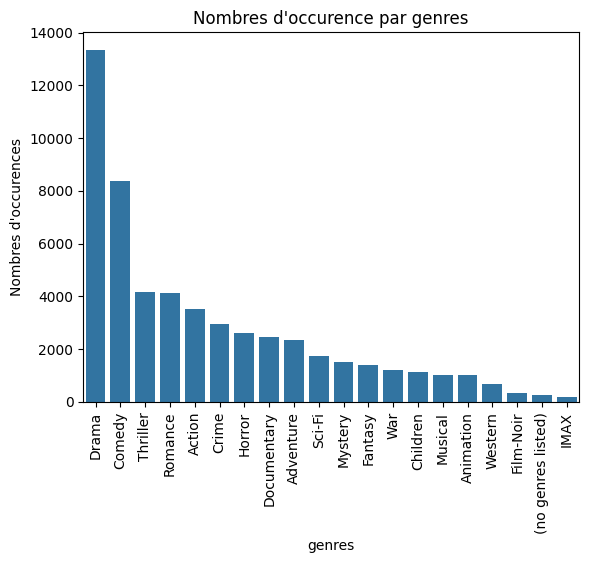

In [115]:
genrecount = movies['genres'].str.split('|').explode().value_counts()
sns.barplot(x=genrecount.index, y=genrecount.values)
plt.xticks(rotation=90)
plt.ylabel("Nombres d'occurences")
plt.title("Nombres d'occurence par genres")
plt.show()

On constate que Drama et Comedy dominent largemnet le catalogue , ce qui peut biaiser le système de recommandation
On pourrait se voir recommander du drama même si nous n'en voulons pas  
Par contre nous notons la présence du genre "(no genres listed)". La variable contient donc implicitement des valeurs nulles

*************************  
**RATINGS**  
*************************

In [116]:
ratings = pd.read_csv("ratings.csv")
display(ratings.head(2))
print(ratings.info(show_counts=True))
print(ratings.shape)

,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676


<class 'pandas.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Non-Null Count     Dtype  
---  ------     --------------     -----  
 0   userId     20000263 non-null  int64  
 1   movieId    20000263 non-null  int64  
 2   rating     20000263 non-null  float64
 3   timestamp  20000263 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 610.4 MB
None
(20000263, 4)


Il n'y a pas de valeur nulle dans le dataframe  
Le dataframe a 20000263 notes

In [117]:
# conversion du champ date timestamp en datetime
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
display(ratings.head(2))
# vérification de l'unicité des couples (userId, movieId)
print("Nombre de doublons sur le couple (userId, movieId):", ratings.duplicated(subset=['userId', 'movieId']).sum())

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16


Nombre de doublons sur le couple (userId, movieId): 0


Le couple userId, movieId est unique. Chaque utilisateur ne peut donc attribuer qu'une note à un film

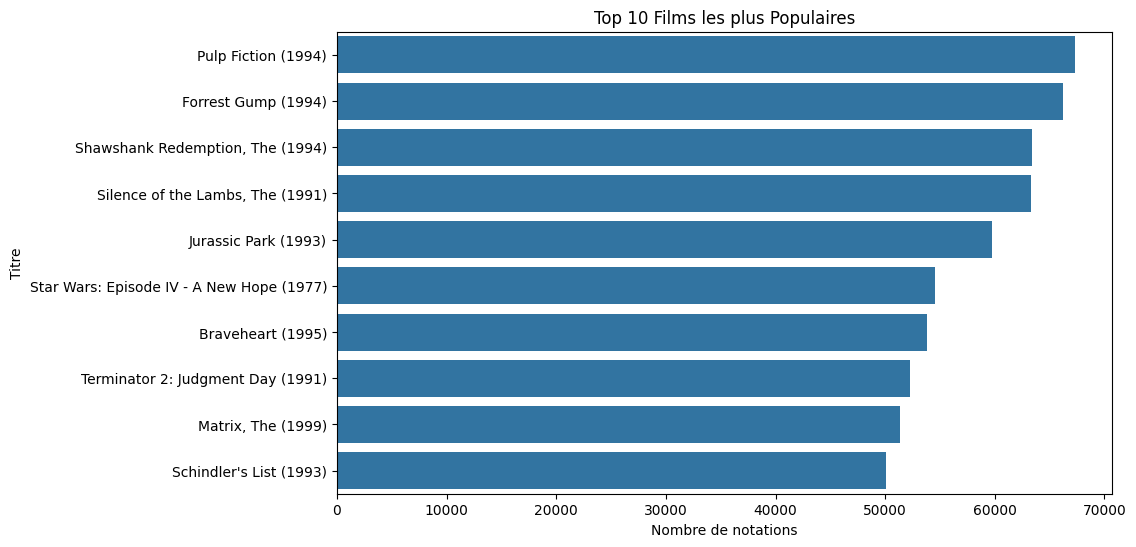

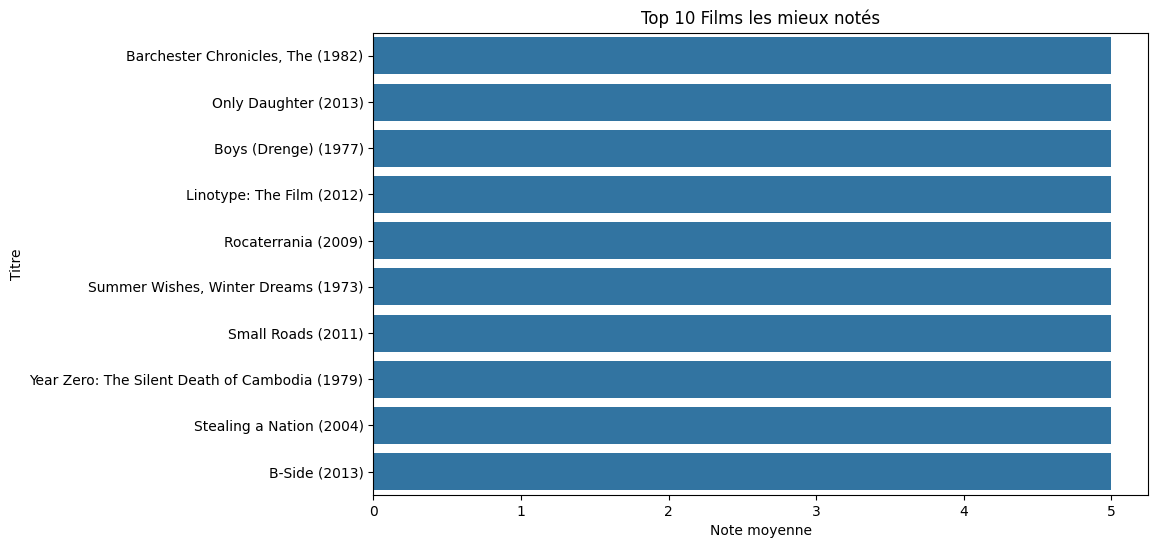

In [118]:
# ajout des titres de film au dataframe ratings
ratings = ratings.merge(movies[['movieId', 'title']], on='movieId', how='left')

# Groupement par movieId et title et calculer la quantité des notations
aggregated_data = ratings.groupby(['movieId', 'title'])['rating'].count().reset_index()
aggregated_data_mn = ratings.groupby(['movieId', 'title'])['rating'].mean().reset_index()

# Tri du DataFrame agrégée par note en ordre décroissant
sorted_aggregated_data = aggregated_data.sort_values(by='rating', ascending=False)
sorted_aggregated_data_mn = aggregated_data_mn.sort_values(by='rating', ascending=False)

# Sélection des 10 premiers films les mieux notés
top_rated_films = sorted_aggregated_data.head(10)
best_rated_films = sorted_aggregated_data_mn.head(10)

# Affichage du graphique
plt.figure(figsize=(10, 6))
sns.barplot(y='title', x='rating', data=top_rated_films, orient = 'h')
plt.xlabel('Nombre de notations')
plt.ylabel('Titre')
plt.title(f'Top 10 Films les plus Populaires')
plt.show()

# ajout du barplot pour les films les mieux notés
plt.figure(figsize=(10, 6))
sns.barplot(y='title', x='rating', data=best_rated_films, orient = 'h')
plt.title(f'Top 10 Films les mieux notés')
plt.xlabel("Note moyenne")
plt.ylabel('Titre')
plt.show()

In [119]:
#Vérifions le nombre de notes pour les films les mieux notés
best_rated_films_with_count = best_rated_films.merge(aggregated_data, on=['movieId', 'title'], how='left')
print(best_rated_films_with_count)

   movieId                                           title  rating_x  rating_y
0    95517               Barchester Chronicles, The (1982)       5.0         1
1   105846                            Only Daughter (2013)       5.0         1
2    89133                            Boys (Drenge) (1977)       5.0         1
3   105187                       Linotype: The Film (2012)       5.0         1
4   105191                             Rocaterrania (2009)       5.0         1
5    88488             Summer Wishes, Winter Dreams (1973)       5.0         1
6   126945                              Small Roads (2011)       5.0         1
7   105526  Year Zero: The Silent Death of Cambodia (1979)       5.0         1
8   105529                        Stealing a Nation (2004)       5.0         1
9   105841                                   B-Side (2013)       5.0         1


Les films les plus populaires (les plus notés) ne sont pas forcément les mieux notés, et on remarque que les films les mieux notés n'ont qu'un seul vote

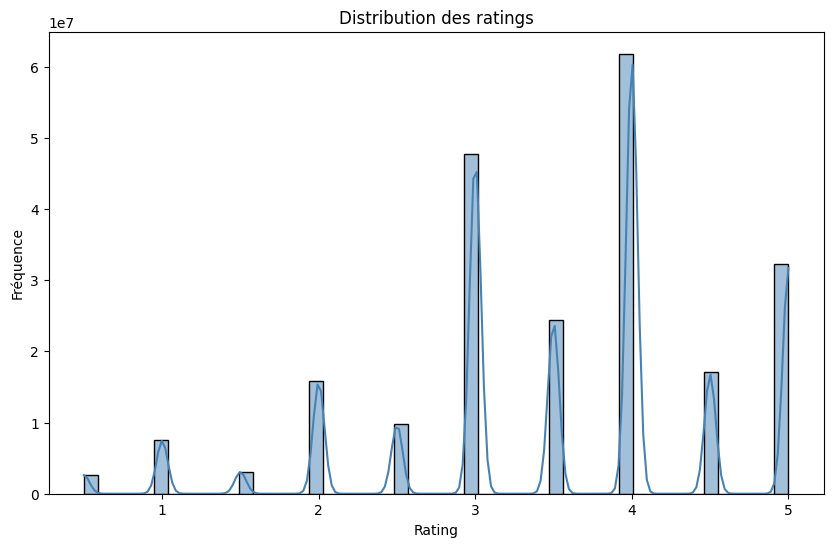

In [120]:
# Création d'un histogramme de la distribution des ratings
plt.figure(figsize=(10, 6))
sns.histplot(data=ratings, x='rating', bins=50, kde=True, stat='frequency', color='steelblue')
plt.xlabel('Rating')
plt.ylabel('Fréquence')
plt.title('Distribution des ratings')
plt.show()

In [121]:
ratings['rating'].describe()

count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

les notes vont de 0,5 à 1

*************************  
LINKS  
*************************

In [122]:
links = pd.read_csv("links.csv")
display(links.head(2))
print(links.info(show_counts=True))
print(links.shape)

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0


<class 'pandas.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  27278 non-null  int64  
 1   imdbId   27278 non-null  int64  
 2   tmdbId   27026 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 639.5 KB
None
(27278, 3)


Il n'y a pas de valeur nulle pour movieId et imdbId. Il y en a dans tmdbId mais ce champ ne nous intéresse pas

In [123]:
#nombre de valeurs uniques pour movieId, imdbId
print("Nombre de valeurs uniques pour movieId :", links['movieId'].nunique())
print("Nombre de valeurs uniques pour imdbId :", links['imdbId'].nunique())

Nombre de valeurs uniques pour movieId : 27278
Nombre de valeurs uniques pour imdbId : 27278


Les identifiants sont bien uniques.   
   
Servons nous des identifiants imdb pour analyser les doublons évoqués plus haut dans movies. Vérifions avec imdb si les doublosn le sont vraiment sur le titre

In [124]:
# ajout de imdbId dans le dataframe contenant les titres dupliqués
dup_titles_links = dup_titles.merge(links, on='movieId', how='left').drop(columns=['tmdbId'])
dup_titles_links.head(2)

,movieId,title,genres,imdbId
0,114130,"20,000 Leagues Under the Sea (1997)",Romance|Sci-Fi,118247
1,102190,"20,000 Leagues Under the Sea (1997)",Adventure|Romance|Sci-Fi,118248


In [125]:
# recuperation des titres dans IMDB
df = pd.read_csv("data/imdb/title.basics.tsv", sep='\t')
df.head(2)

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"


In [126]:
# dans le dataframe df le champ tconst commence par tt000 transformons le champ tconst en entier pour pouvoir le comparer avec le champ imdbId du dataframe links
df['imdbId'] = df['tconst'].str.replace('tt', '').astype(int)
df = df.drop(columns=['tconst'])
df.head(2)   

,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,imdbId
0,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short",1
1,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short",2


In [127]:
# affichons les films dupliqués dans imdb 
df.loc[df['imdbId'].isin(dup_titles_links['imdbId']) ].sort_values(['primaryTitle'], ascending=[True])

,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,imdbId
115464,tvMiniSeries,"20,000 Leagues Under the Sea","20,000 Leagues Under the Sea",0,1997,1997,158,"Adventure,Romance,Sci-Fi",118248
115463,tvMovie,"20,000 Leagues Under the Sea","20,000 Leagues Under the Sea",0,1997,\N,95,"Adventure,Fantasy,Romance",118247
101306,movie,Aladdin,Aladdin,0,1992,\N,90,"Adventure,Animation,Comedy",103639
801392,video,Aladdin,Aladdin,0,1992,\N,49,"Adventure,Animation,Comedy",827990
5885724,movie,Beneath,Beneath,0,2013,\N,90,"Horror,Sci-Fi,Thriller",2325518
7173328,movie,Beneath,Beneath,0,2013,\N,89,"Adventure,Drama,Horror",2991296
796422,movie,Blackout,Blackout,0,2007,\N,95,Drama,822791
817431,movie,Blackout,Blackout,0,2008,\N,85,"Horror,Mystery,Thriller",844666
409387,tvMiniSeries,Casanova,Casanova,0,2005,2005,58,"Biography,Comedy,Drama",427042
385877,movie,Casanova,Casanova,0,2005,\N,112,"Adventure,Comedy,Drama",402894


Nous pouvons constater que bien qu'ayant le même titre, les films sont différents. Ils n'ont pas le même genre, ni la même durée. On distingue des oeuvres pour le cinéma et des oeuvres pour la télévision. Nous allons donc conserver ces titres qui ont des identifiants différents.

*************************  
TAGS  
*************************

In [128]:
tags = pd.read_csv("tags.csv")
display(tags.head(2))
print(tags.info(show_counts=True))
print(tags.shape)

,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,1240597180
1,65,208,dark hero,1368150078


<class 'pandas.DataFrame'>
RangeIndex: 465564 entries, 0 to 465563
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   userId     465564 non-null  int64
 1   movieId    465564 non-null  int64
 2   tag        465548 non-null  str  
 3   timestamp  465564 non-null  int64
dtypes: int64(3), str(1)
memory usage: 14.2 MB
None
(465564, 4)


Il y a des valeurs nulles dans la colonne tag

In [129]:
print(tags.isna().sum())
print(tags[tags['tag'].isna()])

userId        0
movieId       0
tag          16
timestamp     0
dtype: int64
        userId  movieId  tag   timestamp
373276  116460      123  NaN  1199450867
373277  116460      346  NaN  1199451946
373281  116460     1184  NaN  1199452261
373288  116460     1785  NaN  1199452006
373289  116460     2194  NaN  1199450677
373291  116460     2691  NaN  1199451002
373299  116460     4103  NaN  1199451920
373301  116460     4473  NaN  1199451040
373303  116460     4616  NaN  1199452441
373319  116460     7624  NaN  1199452266
373325  116460     8898  NaN  1199450757
373332  116460    32460  NaN  1199450901
373334  116460    33826  NaN  1199450703
373339  116460    36537  NaN  1199450736
373340  116460    55805  NaN  1199450941
454615  133634    33826  NaN  1221450908


In [130]:
#nombre de valeurs uniques pour userId, movieId
print("Nombre de valeurs uniques pour userId :", tags['userId'].nunique())
print("Nombre de valeurs uniques pour movieId :", tags['movieId'].nunique())
# vérification de l'unicité des couples (userId, movieId)
print("Nombre de doublons sur le couple (userId, movieId):", tags.duplicated(subset=['userId', 'movieId']).sum())
print("Nombre de doublons sur le triplet (userId, movieId, tag):", tags.duplicated(subset=['userId', 'movieId', 'tag']).sum())

Nombre de valeurs uniques pour userId : 7801
Nombre de valeurs uniques pour movieId : 19545
Nombre de doublons sur le couple (userId, movieId): 290720
Nombre de doublons sur le triplet (userId, movieId, tag): 0


Le couple (userId, movieId) n'est pas unique. Un utilisateur peut donc avoir plusieurs tags sur un même film. Par contre le même tag n'est pas dupliqué pour le triplet userId, movieId, tag

In [131]:
# pour poursuivre l'analyse nous allons supprimer les tags nuls
tags = tags.dropna()
print(tags.isna().sum())
print(tags.shape)

userId       0
movieId      0
tag          0
timestamp    0
dtype: int64
(465548, 4)


Nombre de mots dans les tags :  779217


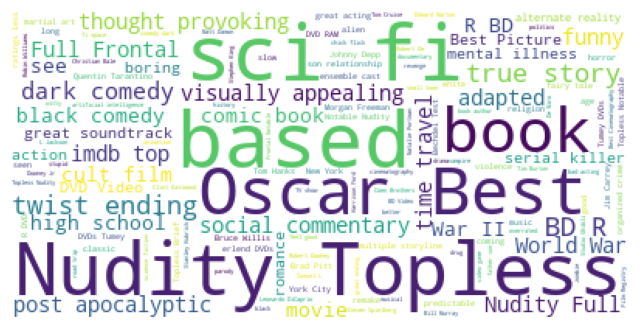

In [132]:
# affichage des mots dominants dans les tags des films
text = " ".join(tags['tag'])

print("Nombre de mots dans les tags : ", len(text.split()))

stop_words = set(stopwords.words('english'))

# Définir le calque du nuage des mots
wc = WordCloud(background_color="white", max_words=1000, stopwords=stop_words, max_font_size=50, random_state=42)
# Générer et afficher le nuage de mots
plt.figure(figsize= (8,6)) # Initialisation d'une figure
wc.generate(text)           # "Calcul" du wordcloud
plt.imshow(wc) # Affichage
plt.axis('off')  # supprime les axes numériques
plt.show()

*************************  
GENOME TAGS  
*************************

In [ ]:
genome_tags = pd.read_csv("genome-tags.csv")
display(genome_tags.head(2))
print(genome_tags.info(show_counts=True))
print(genome_tags.shape)

,tagId,tag
0,1,007
1,2,007 (series)


<class 'pandas.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   tagId   1128 non-null   int64
 1   tag     1128 non-null   str  
dtypes: int64(1), str(1)
memory usage: 17.8 KB
None
(1128, 2)


In [134]:
print("Nombre de valeurs uniques pour tagId :", genome_tags['tagId'].nunique())
print("Nombre de valeurs uniques pour tag :", genome_tags['tag'].nunique())
print("Nombre de doublons sur le couple (tagId, tag):", genome_tags.duplicated(subset=['tagId', 'tag']).sum())

Nombre de valeurs uniques pour tagId : 1128
Nombre de valeurs uniques pour tag : 1128
Nombre de doublons sur le couple (tagId, tag): 0


*************************  
GENOME SCORES  
*************************

In [ ]:
genome_scores = pd.read_csv("genome-scores.csv")
display(genome_scores.head(2))
print(genome_scores.info(show_counts=True))
print(genome_tags.shape)

,movieId,tagId,relevance
0,1,1,0.025
1,1,2,0.025


<class 'pandas.DataFrame'>
RangeIndex: 11709768 entries, 0 to 11709767
Data columns (total 3 columns):
 #   Column     Non-Null Count     Dtype  
---  ------     --------------     -----  
 0   movieId    11709768 non-null  int64  
 1   tagId      11709768 non-null  int64  
 2   relevance  11709768 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 268.0 MB
None
(1128, 2)


In [136]:
print("Nombre de valeurs uniques pour movieId :", genome_scores['movieId'].nunique())
print("Nombre de valeurs uniques pour tagId :", genome_scores['tagId'].nunique())
print("Nombre de doublons sur le couple (movieId, tagId):", genome_scores.duplicated(subset=['movieId', 'tagId']).sum())

Nombre de valeurs uniques pour movieId : 10381
Nombre de valeurs uniques pour tagId : 1128
Nombre de doublons sur le couple (movieId, tagId): 0


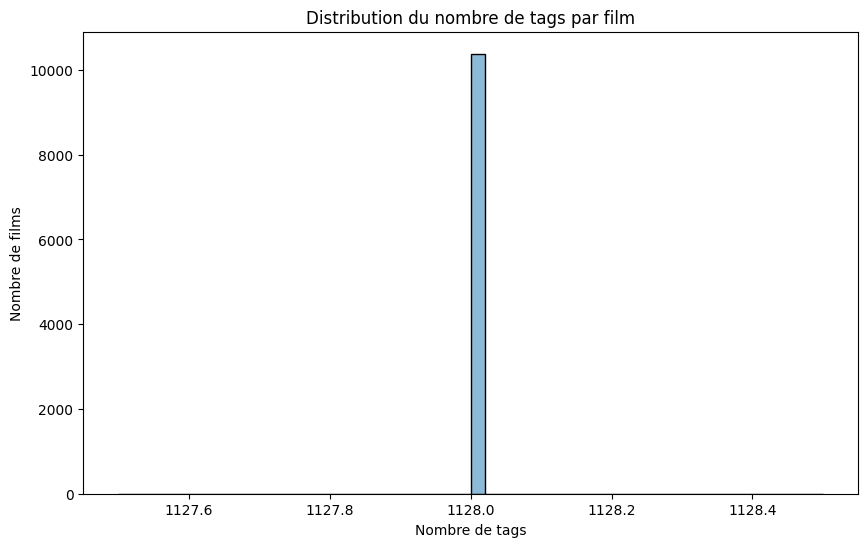

In [137]:
# nombre de tags par film
tags_per_movie = genome_scores['movieId'].value_counts().reset_index()
tags_per_movie.columns = ['movieId', 'tag_count']

# affichage du graphique
plt.figure(figsize=(10, 6))
sns.histplot(data=tags_per_movie, x='tag_count', bins=50, kde=True)
plt.xlabel('Nombre de tags')
plt.ylabel('Nombre de films')
plt.title('Distribution du nombre de tags par film')
plt.show()

Tous les films ont exactement le même nombre de tags (1128). Il s'agit donc d'un score sur chaque tag

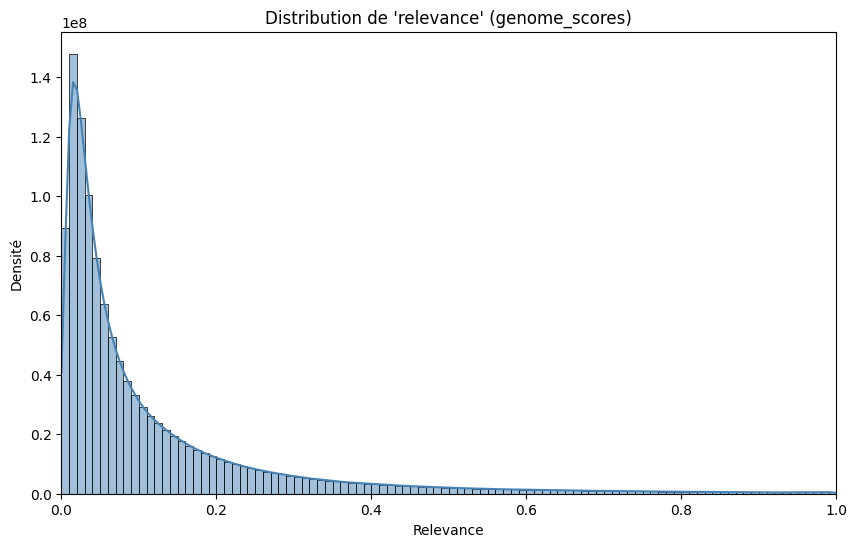

In [138]:
# distribution de la colonne 'relevance' dans genome_scores
plt.figure(figsize=(10,6))
sns.histplot(genome_scores['relevance'], bins=100, kde=True, stat='frequency', color='steelblue')
plt.xlabel('Relevance')
plt.ylabel('Densité')
plt.title("Distribution de 'relevance' (genome_scores)")
plt.xlim(0, 1)
plt.show()

In [139]:
genome_scores['relevance'].describe()

count    1.170977e+07
mean     1.164833e-01
std      1.542463e-01
min      2.500000e-04
25%      2.425000e-02
50%      5.650000e-02
75%      1.415000e-01
max      1.000000e+00
Name: relevance, dtype: float64

Les valeurs de relevance vont de 0 à 1